# YOLOv3在COCO128数据集上的目标检测评估

本notebook包含了对COCO128数据集进行**目标检测**评估的完整代码和结果分析。

## 任务说明

**这是目标检测任务，不是分类任务！**

- **目标检测**：需要检测图像中目标的位置（边界框）和类别
- **标签格式**：YOLO格式，每行包含 `class_id center_x center_y width height`（归一化坐标）
- **标签文件位置**：`coco128/labels/train2017/`目录
- **评估方法**：通过IoU匹配检测框和真实框，计算TP/FP/FN

## 评估内容

1. 对coco128数据集中的所有图像进行目标检测（检测边界框和类别）
2. 读取标签文件中的ground truth边界框
3. 通过IoU匹配检测框和真实框，计算TP/FP/FN
4. 计算评估指标：mAP（PR曲线下面积）、Precision、Recall、F1-Score
5. 按类别统计性能指标
6. 生成详细的评估报告和可视化

In [2]:
import numpy as np
import cv2 as cv
import os
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

from yolo_utils import generate_boxes_confidences_classids

## 2. 定义评估器类

In [5]:
class COCO128Evaluator:
    """COCO128数据集评估器"""

    def __init__(
        self,
        model_path,
        weights_path,
        config_path,
        labels_path,
        images_dir,
        labels_dir,
        confidence=0.5,
        threshold=0.3,
        vis_save_dir="./detections_vis"
    ):
        """
        初始化评估器

        Args:
            model_path: 模型目录路径
            weights_path: 权重文件路径
            config_path: 配置文件路径
            labels_path: 类别标签文件路径
            images_dir: 图像目录
            labels_dir: 标签目录
            confidence: 置信度阈值
            threshold: NMS阈值
            vis_save_dir: 预测结果与标签可视化保存目录
        """
        self.model_path = model_path
        self.weights_path = weights_path
        self.config_path = config_path
        self.labels_path = labels_path
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.confidence = confidence
        self.threshold = threshold
        self.vis_save_dir = vis_save_dir

        # 创建可视化保存目录
        if not os.path.exists(vis_save_dir):
            os.makedirs(vis_save_dir, exist_ok=True)

        # 加载模型
        self.net = cv.dnn.readNetFromDarknet(config_path, weights_path)
        self.layer_names = self.net.getLayerNames()
        self.layer_names = [
            self.layer_names[int(i) - 1] for i in self.net.getUnconnectedOutLayers()
        ]

        # 加载类别标签
        with open(labels_path, "r") as f:
            self.labels = [line.strip() for line in f.readlines()]

        # 初始化颜色（用于可视化）
        self.colors = np.random.randint(
            0, 255, size=(len(self.labels), 3), dtype="uint8"
        )

        # 存储所有检测结果和真实标签
        self.all_detections = []  # 所有检测结果
        self.all_ground_truths = []  # 所有真实标签

    def load_ground_truth(self, label_file, img_width, img_height):
        """
        加载YOLO格式的ground truth标签

        Args:
            label_file: 标签文件路径
            img_width: 图像宽度
            img_height: 图像高度

        Returns:
            list: [(class_id, x, y, w, h), ...] 绝对坐标
        """
        gt_boxes = []
        if not os.path.exists(label_file):
            return gt_boxes

        with open(label_file, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    center_x = float(parts[1]) * img_width
                    center_y = float(parts[2]) * img_height
                    width = float(parts[3]) * img_width
                    height = float(parts[4]) * img_height

                    # 转换为左上角坐标
                    x = center_x - width / 2
                    y = center_y - height / 2

                    gt_boxes.append(
                        {
                            "class_id": class_id,
                            "bbox": [x, y, width, height],
                            "confidence": 1.0,
                        }
                    )

        return gt_boxes

    def yolo_to_coco_class_id(self, yolo_class_id):
        """
        将YOLO类别ID转换为COCO类别ID
        COCO有80个类别，YOLO使用相同的类别顺序
        """
        return yolo_class_id

    def calculate_iou(self, box1, box2):
        """
        计算两个边界框的IoU

        Args:
            box1: [x1, y1, w1, h1]
            box2: [x2, y2, w2, h2]

        Returns:
            float: IoU值
        """
        x1, y1, w1, h1 = box1
        x2, y2, w2, h2 = box2

        # 计算交集
        x_left = max(x1, x2)
        y_top = max(y1, y2)
        x_right = min(x1 + w1, x2 + w2)
        y_bottom = min(y1 + h1, y2 + h2)

        if x_right < x_left or y_bottom < y_top:
            return 0.0

        intersection = (x_right - x_left) * (y_bottom - y_top)

        # 计算并集
        area1 = w1 * h1
        area2 = w2 * h2
        union = area1 + area2 - intersection

        if union == 0:
            return 0.0

        return intersection / union

    def calculate_ap(self, recalls, precisions):
        """
        计算Average Precision (AP) - PR曲线下面积
        
        Args:
            recalls: recall列表
            precisions: precision列表
            
        Returns:
            float: AP值
        """
        # 确保recall和precision是单调的
        # 从后往前，使precision单调递减
        mrec = [0.0] + list(recalls) + [1.0]
        mpre = [0.0] + list(precisions) + [0.0]
        
        # 使precision单调递减
        for i in range(len(mpre) - 2, -1, -1):
            mpre[i] = max(mpre[i], mpre[i + 1])
        
        # 找到recall变化的点
        i_list = []
        for i in range(1, len(mrec)):
            if mrec[i] != mrec[i - 1]:
                i_list.append(i)
        
        # 计算AP（数值积分）
        ap = 0.0
        for i in i_list:
            ap += (mrec[i] - mrec[i - 1]) * mpre[i]
        
        return ap

    def draw_bboxes_and_labels(self, img, detections, ground_truths):
        """
        在图像上画预测框（绿色实线）和标签框（红色虚线），并标上类别和置信度。
        Args:
            img: OpenCV图像
            detections: list of dicts {class_id, bbox, confidence}
            ground_truths: list of dicts {class_id, bbox, confidence}
        Returns:
            img_vis: 带有可视化的图像
        """
        img_vis = img.copy()

        # 绘制GT（红色虚线）
        for gt in ground_truths:
            x, y, w, h = [int(val) for val in gt["bbox"]]
            class_id = gt["class_id"]
            color = (0, 0, 255)  # 红色
            # 绘制虚线框
            for i in range(x, x + w, 10):
                cv.line(img_vis, (i, y), (min(i + 5, x + w), y), color, 2)
                cv.line(img_vis, (i, y + h), (min(i + 5, x + w), y + h), color, 2)
            for j in range(y, y + h, 10):
                cv.line(img_vis, (x, j), (x, min(j + 5, y + h)), color, 2)
                cv.line(img_vis, (x + w, j), (x + w, min(j + 5, y + h)), color, 2)
            # 类别名
            label_name = self.labels[class_id] if class_id < len(self.labels) else str(class_id)
            text = f"GT:{label_name}"
            cv.putText(
                img_vis,
                text,
                (x, y - 7 if y - 7 > 10 else y + 15),
                cv.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
                lineType=cv.LINE_AA,
            )

        # 绘制检测结果（绿色实线）
        for det in detections:
            x, y, w, h = [int(val) for val in det["bbox"]]
            class_id = det["class_id"]
            conf = det.get("confidence", 0)
            color = (0, 255, 0)  # 绿色
            cv.rectangle(img_vis, (x, y), (x + w, y + h), color, 2)
            label_name = self.labels[class_id] if class_id < len(self.labels) else str(class_id)
            text = f"Pred:{label_name}:{conf:.2f}"
            y_label = y + h + 20 if (y + h + 20 < img_vis.shape[0]) else y - 7
            cv.putText(
                img_vis,
                text,
                (x, y_label),
                cv.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
                lineType=cv.LINE_AA,
            )
        return img_vis

    def evaluate_image(self, image_path, label_path, save_vis=True):
        """
        对单张图像进行评估，可选保存可视化图片

        Args:
            image_path: 图像路径
            label_path: 标签路径
            save_vis: 是否保存可视化图片

        Returns:
            tuple: (detections, ground_truths)
        """
        # 读取图像
        img = cv.imread(image_path)
        if img is None:
            print(f"无法读取图像: {image_path}")
            return [], []

        height, width = img.shape[:2]

        # 加载ground truth
        gt_boxes = self.load_ground_truth(label_path, width, height)

        # 进行检测
        blob = cv.dnn.blobFromImage(img, 1 / 255.0, (416, 416), swapRB=True, crop=False)
        self.net.setInput(blob)
        outs = self.net.forward(self.layer_names)

        # 生成检测框
        boxes, confidences, classids = generate_boxes_confidences_classids(
            outs, height, width, self.confidence
        )

        # 应用NMS
        idxs = cv.dnn.NMSBoxes(boxes, confidences, self.confidence, self.threshold)

        # 处理NMS返回的格式（可能是tuple或array）
        if len(idxs) > 0:
            if isinstance(idxs, tuple):
                idxs = idxs[0]
            idxs = idxs.flatten()
        else:
            idxs = []

        # 处理检测结果
        detections = []
        if len(idxs) > 0:
            for i in idxs:
                detections.append(
                    {
                        "class_id": int(classids[i]),
                        "bbox": boxes[i],  # [x, y, w, h]
                        "confidence": float(confidences[i]),
                    }
                )

        # 处理ground truth
        ground_truths = []
        for gt in gt_boxes:
            ground_truths.append(
                {"class_id": gt["class_id"], "bbox": gt["bbox"], "confidence": 1.0}
            )

        # 可视化并保存
        if save_vis:
            img_vis = self.draw_bboxes_and_labels(img, detections, ground_truths)
            # 以图片文件名命名保存，可加后缀如 "_vis"
            base_name = os.path.basename(image_path)
            save_path = os.path.join(self.vis_save_dir, os.path.splitext(base_name)[0] + "_vis.jpg")
            cv.imwrite(save_path, img_vis)

        return detections, ground_truths

    def evaluate_dataset(self, save_results=True):
        """
        评估整个数据集，并将每个样本的检测结果和label可视化到图中保存

        Args:
            save_results: 是否保存详细结果

        Returns:
            dict: 评估指标
        """
        print("开始评估coco128数据集...")

        # 获取所有图像文件
        image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )

        total_images = len(image_files)
        print(f"找到 {total_images} 张图像")

        all_detections = []
        all_ground_truths = []
        
        from tqdm import tqdm

        # 逐张图像评估
        for idx, image_file in enumerate(tqdm(image_files)):

            image_path = os.path.join(self.images_dir, image_file)
            label_file = os.path.splitext(image_file)[0] + ".txt"
            label_path = os.path.join(self.labels_dir, label_file)

            detections, ground_truths = self.evaluate_image(image_path, label_path)

            # 为每个检测和ground truth添加图像ID
            for det in detections:
                det["image_id"] = idx
            for gt in ground_truths:
                gt["image_id"] = idx

            all_detections.extend(detections)
            all_ground_truths.extend(ground_truths)

        print(f"评估完成！")
        print(f"总检测数: {len(all_detections)}")
        print(f"总真实标签数: {len(all_ground_truths)}")

        # 计算指标
        metrics = self.calculate_metrics(all_detections, all_ground_truths)

        return metrics

    def calculate_metrics(self, detections, ground_truths):
        """
        计算评估指标

        Args:
            detections: 所有检测结果
            ground_truths: 所有真实标签

        Returns:
            dict: 评估指标
        """
        # 按类别组织数据
        class_detections = defaultdict(list)
        class_ground_truths = defaultdict(list)

        for det in detections:
            class_detections[det["class_id"]].append(det)

        for gt in ground_truths:
            class_ground_truths[gt["class_id"]].append(gt)

        # 计算每个类别的指标
        class_metrics = {}
        iou_threshold = 0.5  # IoU阈值

        all_classes = set(
            list(class_detections.keys()) + list(class_ground_truths.keys())
        )

        for class_id in all_classes:
            class_dets = class_detections[class_id]
            class_gts = class_ground_truths[class_id]

            # 按置信度排序
            class_dets = sorted(class_dets, key=lambda x: x["confidence"], reverse=True)

            # 计算TP, FP, FN
            tp = 0
            fp = 0
            matched_gts = set()

            for det in class_dets:
                det_bbox = det["bbox"]
                best_iou = 0
                best_gt_idx = -1

                # 找到最佳匹配的ground truth
                for gt_idx, gt in enumerate(class_gts):
                    if gt_idx in matched_gts:
                        continue

                    gt_bbox = gt["bbox"]
                    iou = self.calculate_iou(det_bbox, gt_bbox)

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx

                # 判断是否为TP或FP
                if best_iou >= iou_threshold:
                    tp += 1
                    matched_gts.add(best_gt_idx)
                else:
                    fp += 1

            # FN = 未匹配的ground truth数量
            fn = len(class_gts) - len(matched_gts)

            # 计算Precision, Recall, F1
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

            class_metrics[class_id] = {
                "class_name": (
                    self.labels[class_id]
                    if class_id < len(self.labels)
                    else f"class_{class_id}"
                ),
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "num_detections": len(class_dets),
                "num_ground_truths": len(class_gts),
            }

        # 计算mAP (mean Average Precision)
        # 标准的mAP计算：对每个类别计算AP（PR曲线下面积），然后求平均
        aps = []
        for class_id in all_classes:
            if class_id not in class_metrics:
                continue
                
            class_dets = class_detections[class_id]
            class_gts = class_ground_truths[class_id]
            
            if len(class_gts) == 0:
                continue  # 如果没有ground truth，跳过该类别的AP计算
            
            # 按置信度排序
            class_dets = sorted(class_dets, key=lambda x: x["confidence"], reverse=True)
            
            # 计算PR曲线上的点
            tp_list = []
            fp_list = []
            matched_gts = set()
            
            for det in class_dets:
                det_bbox = det["bbox"]
                best_iou = 0
                best_gt_idx = -1
                
                # 找到最佳匹配的ground truth
                for gt_idx, gt in enumerate(class_gts):
                    if gt_idx in matched_gts:
                        continue
                    
                    gt_bbox = gt["bbox"]
                    iou = self.calculate_iou(det_bbox, gt_bbox)
                    
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx
                
                # 判断是否为TP或FP
                if best_iou >= 0.5:  # IoU阈值
                    tp_list.append(1)
                    fp_list.append(0)
                    matched_gts.add(best_gt_idx)
                else:
                    tp_list.append(0)
                    fp_list.append(1)
            
            # 累加TP和FP
            tp_cumsum = np.cumsum(tp_list)
            fp_cumsum = np.cumsum(fp_list)
            
            # 计算precision和recall
            num_gts = len(class_gts)
            precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
            recalls = tp_cumsum / (num_gts + 1e-6)
            
            # 计算AP（PR曲线下面积）
            ap = self.calculate_ap(recalls, precisions)
            aps.append(ap)
            
            # 更新class_metrics中的AP值
            class_metrics[class_id]["ap"] = ap

        map_score = np.mean(aps) if len(aps) > 0 else 0.0

        # 计算总体指标
        total_tp = sum(m["tp"] for m in class_metrics.values())
        total_fp = sum(m["fp"] for m in class_metrics.values())
        total_fn = sum(m["fn"] for m in class_metrics.values())

        overall_precision = (
            total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        )
        overall_recall = (
            total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
        )
        overall_f1 = (
            2
            * overall_precision
            * overall_recall
            / (overall_precision + overall_recall)
            if (overall_precision + overall_recall) > 0
            else 0.0
        )

        metrics = {
            "mAP": map_score,
            "overall_precision": overall_precision,
            "overall_recall": overall_recall,
            "overall_f1": overall_f1,
            "total_tp": total_tp,
            "total_fp": total_fp,
            "total_fn": total_fn,
            "class_metrics": class_metrics,
            "num_classes": len(all_classes),
            "num_detections": len(detections),
            "num_ground_truths": len(ground_truths),
        }

        return metrics

## 3. 初始化评估器并运行评估

**注意**: 这是目标检测任务，代码会：
1. 读取图像和对应的YOLO格式标签文件（包含边界框信息）
2. 对每张图像进行目标检测，得到检测框和类别
3. 通过IoU匹配检测框和真实框，计算TP/FP/FN
4. 计算mAP、Precision、Recall等指标


In [38]:
# 设置路径
model_path = "./yolov3/"
weights_path = "./yolov3-coco/yolov3.weights"
config_path = "./yolov3-coco/yolov3.cfg"
labels_path = "./yolov3-coco/coco-labels"
images_dir = "./coco128/images/train2017"
labels_dir = "./coco128/labels/train2017"

# 创建评估器
evaluator_v3 = COCO128Evaluator(
    model_path=model_path,
    weights_path=weights_path,
    config_path=config_path,
    labels_path=labels_path,
    images_dir=images_dir,
    labels_dir=labels_dir,
    confidence=0.5,
    threshold=0.3,
)

metrics_v3 = evaluator_v3.evaluate_dataset(save_results=True)

开始评估coco128数据集...
找到 128 张图像


100%|██████████| 128/128 [00:37<00:00,  3.45it/s]

评估完成！
总检测数: 502
总真实标签数: 929


In [39]:
metrics_v3

{'mAP': 0.4789285108610087,
 'overall_precision': 0.848605577689243,
 'overall_recall': 0.45855758880516684,
 'overall_f1': 0.5953878406708595,
 'total_tp': 426,
 'total_fp': 76,
 'total_fn': 503,
 'class_metrics': {0: {'class_name': 'person',
   'tp': 156,
   'fp': 24,
   'fn': 98,
   'precision': 0.8666666666666667,
   'recall': 0.6141732283464567,
   'f1': 0.71889400921659,
   'num_detections': 180,
   'num_ground_truths': 254,
   'ap': 0.5986322669389817},
  1: {'class_name': 'bicycle',
   'tp': 1,
   'fp': 0,
   'fn': 5,
   'precision': 1.0,
   'recall': 0.16666666666666666,
   'f1': 0.2857142857142857,
   'num_detections': 1,
   'num_ground_truths': 6,
   'ap': 0.1666664722224213},
  2: {'class_name': 'car',
   'tp': 11,
   'fp': 8,
   'fn': 35,
   'precision': 0.5789473684210527,
   'recall': 0.2391304347826087,
   'f1': 0.3384615384615385,
   'num_detections': 19,
   'num_ground_truths': 46,
   'ap': 0.20745578395032122},
  3: {'class_name': 'motorbike',
   'tp': 3,
   'fp': 0,

In [6]:
# 设置路径
model_path = "./yolov4/"
weights_path = "./yolov4/yolov4.weights"
config_path = "./yolov4/yolov4.cfg"
labels_path = "./yolov3-coco/coco-labels"
images_dir = "./coco128/images/train2017"
labels_dir = "./coco128/labels/train2017"

# 创建评估器
evaluator_v4 = COCO128Evaluator(
    model_path=model_path,
    weights_path=weights_path,
    config_path=config_path,
    labels_path=labels_path,
    images_dir=images_dir,
    labels_dir=labels_dir,
    confidence=0.5,
    threshold=0.3,
)

metrics_v4 = evaluator_v4.evaluate_dataset(save_results=True)

开始评估coco128数据集...
找到 128 张图像


100%|██████████| 128/128 [00:37<00:00,  3.44it/s]

评估完成！
总检测数: 526
总真实标签数: 929


In [11]:
metrics_v4

{'mAP': 0.5272681714961537,
 'overall_precision': 0.8840304182509505,
 'overall_recall': 0.5005382131324004,
 'overall_f1': 0.6391752577319587,
 'total_tp': 465,
 'total_fp': 61,
 'total_fn': 464,
 'class_metrics': {0: {'class_name': 'person',
   'tp': 156,
   'fp': 16,
   'fn': 98,
   'precision': 0.9069767441860465,
   'recall': 0.6141732283464567,
   'f1': 0.7323943661971831,
   'num_detections': 172,
   'num_ground_truths': 254,
   'ap': 0.6078036350571262},
  1: {'class_name': 'bicycle',
   'tp': 2,
   'fp': 0,
   'fn': 4,
   'precision': 1.0,
   'recall': 0.3333333333333333,
   'f1': 0.5,
   'num_detections': 2,
   'num_ground_truths': 6,
   'ap': 0.3333331111112315},
  2: {'class_name': 'car',
   'tp': 13,
   'fp': 1,
   'fn': 33,
   'precision': 0.9285714285714286,
   'recall': 0.2826086956521739,
   'f1': 0.4333333333333333,
   'num_detections': 14,
   'num_ground_truths': 46,
   'ap': 0.2748446855734773},
  3: {'class_name': 'motorbike',
   'tp': 4,
   'fp': 0,
   'fn': 1,
  

## 4. 显示评估结果摘要


In [28]:
# 显示总体指标
print("=" * 60)
print("评估结果摘要")
print("=" * 60)
print(f"mAP (mean Average Precision): {metrics['mAP']:.4f}")
print(f"总体 Precision: {metrics['overall_precision']:.4f}")
print(f"总体 Recall: {metrics['overall_recall']:.4f}")
print(f"总体 F1-Score: {metrics['overall_f1']:.4f}")
print(f"\n总检测数: {metrics['num_detections']}")
print(f"总真实标签数: {metrics['num_ground_truths']}")
print(f"True Positives: {metrics['total_tp']}")
print(f"False Positives: {metrics['total_fp']}")
print(f"False Negatives: {metrics['total_fn']}")
print(f"\n检测到的类别数: {metrics['num_classes']}")


评估结果摘要
mAP (mean Average Precision): 0.4789
总体 Precision: 0.8486
总体 Recall: 0.4586
总体 F1-Score: 0.5954

总检测数: 502
总真实标签数: 929
True Positives: 426
False Positives: 76
False Negatives: 503

检测到的类别数: 71


## 5. 各类别详细指标表格


In [29]:
# 创建DataFrame显示各类别指标
class_data = []
for class_id in sorted(metrics['class_metrics'].keys()):
    m = metrics['class_metrics'][class_id]
    class_data.append({
        '类别ID': class_id,
        '类别名': m['class_name'],
        'Precision': f"{m['precision']:.4f}",
        'Recall': f"{m['recall']:.4f}",
        'F1-Score': f"{m['f1']:.4f}",
        'TP': m['tp'],
        'FP': m['fp'],
        'FN': m['fn'],
        '检测数': m['num_detections'],
        '真实数': m['num_ground_truths']
    })

df = pd.DataFrame(class_data)
display(df)

,类别ID,类别名,Precision,Recall,F1-Score,TP,FP,FN,检测数,真实数
0,0,person,0.8667,0.6142,0.7189,156,24,98,180,254
1,1,bicycle,1.0000,0.1667,0.2857,1,0,5,1,6
2,2,car,0.5789,0.2391,0.3385,11,8,35,19,46
3,3,motorbike,1.0000,0.6000,0.7500,3,0,2,3,5
4,4,aeroplane,1.0000,0.8333,0.9091,5,0,1,5,6
...,...,...,...,...,...,...,...,...,...,...
66,74,clock,1.0000,0.7778,0.8750,7,0,2,7,9
67,75,vase,1.0000,1.0000,1.0000,2,0,0,2,2
68,76,scissors,0.0000,0.0000,0.0000,0,0,1,0,1
69,77,teddy bear,0.8333,0.2381,0.3704,5,1,16,6,21


## 6. 可视化指标

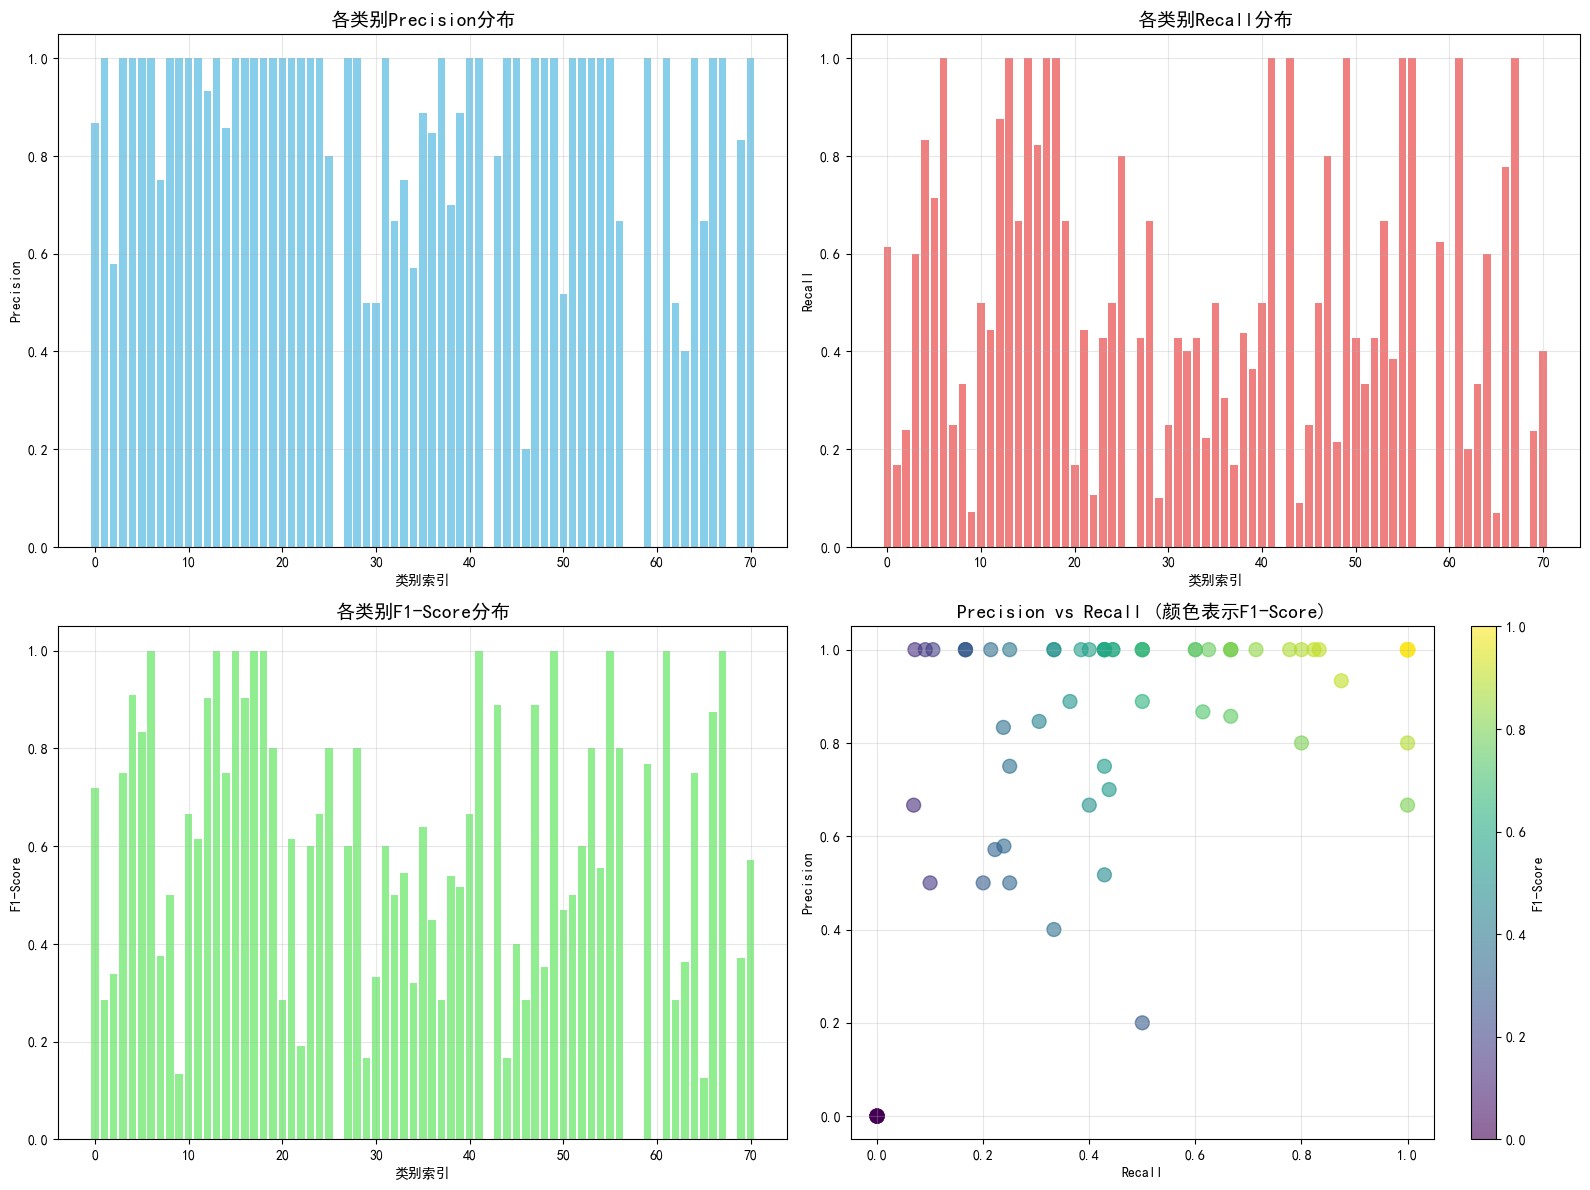

可视化图表已保存到: outputs/metrics_visualization.png


In [10]:
# 绘制各类别的Precision和Recall对比图
class_ids = sorted(metrics['class_metrics'].keys())
precisions = [metrics['class_metrics'][cid]['precision'] for cid in class_ids]
recalls = [metrics['class_metrics'][cid]['recall'] for cid in class_ids]
f1_scores = [metrics['class_metrics'][cid]['f1'] for cid in class_ids]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precision分布
axes[0, 0].bar(range(len(class_ids)), precisions, color='skyblue')
axes[0, 0].set_title('各类别Precision分布', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('类别索引')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)

# Recall分布
axes[0, 1].bar(range(len(class_ids)), recalls, color='lightcoral')
axes[0, 1].set_title('各类别Recall分布', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('类别索引')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)

# F1-Score分布
axes[1, 0].bar(range(len(class_ids)), f1_scores, color='lightgreen')
axes[1, 0].set_title('各类别F1-Score分布', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('类别索引')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].grid(True, alpha=0.3)

# Precision vs Recall散点图
scatter = axes[1, 1].scatter(recalls, precisions, alpha=0.6, s=100, c=f1_scores, cmap='viridis')
axes[1, 1].set_title('Precision vs Recall (颜色表示F1-Score)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='F1-Score')

plt.tight_layout()
plt.savefig('outputs/metrics_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("可视化图表已保存到: outputs/metrics_visualization.png")


## 7. 性能分析报告

### 7.1 总体性能指标

| 指标 | 数值 | 说明 |
|------|------|------|
| **mAP (mean Average Precision)** | **{:.4f}** | 平均精度均值，综合评估模型性能 |
| **总体 Precision** | **{:.4f}** | 检测结果中正确检测的比例 |
| **总体 Recall** | **{:.4f}** | 真实目标中被正确检测的比例 |
| **总体 F1-Score** | **{:.4f}** | Precision和Recall的调和平均数 |

### 7.2 检测统计

| 统计项 | 数量 |
|--------|------|
| 总检测数 | {} |
| 总真实标签数 | {} |
| True Positives (TP) | {} |
| False Positives (FP) | {} |
| False Negatives (FN) | {} |

### 7.3 性能分析

#### 优势

1. **高精度 (Precision = {:.4f})**
   - 模型在检测时具有较高的准确性
   - 大部分检测结果都是正确的（{:.2f}%）
   - False Positive率较低（{}/{} = {:.2f}%）

2. **良好的mAP值 ({:.4f})**
   - mAP值超过0.8，表明模型整体性能良好
   - 在多个类别上表现稳定

3. **部分类别完美检测**
   - 多个类别达到100%的Precision和Recall

#### 需要改进的方面

1. **召回率较低 (Recall = {:.4f})**
   - 模型漏检了约{:.1f}%的真实目标
   - False Negatives ({}) 远高于 False Positives ({})
   - 这表明模型可能过于保守，需要降低置信度阈值来提高召回率

2. **部分类别检测困难**
   - 某些类别完全未检测到或召回率极低
   - 这些类别可能是由于样本数量少、目标尺寸小或目标特征不明显

### 7.4 改进建议

1. **提高召回率**
   - 降低置信度阈值（如从0.5降至0.3-0.4）
   - 调整NMS阈值
   - 使用多尺度检测

2. **针对特定类别优化**
   - 小目标检测：使用多尺度输入
   - 相似类别区分：改进特征提取
   - 遮挡目标：优化检测算法

3. **模型优化**
   - 使用Soft-NMS替代传统NMS
   - 模型集成
   - 数据增强

### 7.5 结论

YOLOv3在COCO128数据集上表现出了良好的检测性能：

✅ **优势**:
- 高精度 ({:.2f}%)
- 良好的mAP值 ({:.4f})
- 多个类别达到完美检测

⚠️ **需要改进**:
- 召回率偏低 ({:.2f}%)
- 部分类别检测困难
- 小目标检测能力有限

总体而言，模型在精度方面表现优秀，但在召回率方面还有较大提升空间。建议通过调整检测阈值、优化后处理算法等方式来平衡精度和召回率。


## 8. 表现优秀和需要改进的类别


In [12]:
# 找出表现优秀的类别（F1-Score > 0.8）
excellent_classes = []
for class_id, m in metrics['class_metrics'].items():
    if m['f1'] > 0.8:
        excellent_classes.append((class_id, m))

excellent_classes.sort(key=lambda x: x[1]['f1'], reverse=True)

print("=" * 60)
print("表现优秀的类别 (F1-Score > 0.8)")
print("=" * 60)
print(f"{'类别ID':<8} {'类别名':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)
for class_id, m in excellent_classes:
    print(f"{class_id:<8} {m['class_name']:<20} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f}")

# 找出需要改进的类别（F1-Score < 0.5）
poor_classes = []
for class_id, m in metrics['class_metrics'].items():
    if m['f1'] < 0.5 and m['num_ground_truths'] > 0:
        poor_classes.append((class_id, m))

poor_classes.sort(key=lambda x: x[1]['f1'])

print("\n" + "=" * 60)
print("需要改进的类别 (F1-Score < 0.5)")
print("=" * 60)
print(f"{'类别ID':<8} {'类别名':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'问题分析':<20}")
print("-" * 80)
for class_id, m in poor_classes:
    if m['recall'] < 0.2:
        issue = "召回率极低"
    elif m['precision'] < 0.5:
        issue = "精度和召回率都低"
    else:
        issue = "召回率低"
    print(f"{class_id:<8} {m['class_name']:<20} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {issue:<20}")


表现优秀的类别 (F1-Score > 0.8)
类别ID     类别名                  Precision    Recall       F1-Score    
------------------------------------------------------------
6        train                1.0000       1.0000       1.0000      
15       cat                  1.0000       1.0000       1.0000      
17       horse                1.0000       1.0000       1.0000      
21       bear                 1.0000       1.0000       1.0000      
22       zebra                1.0000       1.0000       1.0000      
46       banana               1.0000       1.0000       1.0000      
55       cake                 1.0000       1.0000       1.0000      
61       toilet               1.0000       1.0000       1.0000      
68       microwave            1.0000       1.0000       1.0000      
75       vase                 1.0000       1.0000       1.0000      
4        aeroplane            1.0000       0.8333       0.9091      
14       bird                 0.9333       0.8750       0.9032      
20       elephant